### Кастомный ViT (улучшенный бейзлайн)

Техники как у Top-1 Swin-T: аугментации, 30 эпох, CosineAnnealingLR, label smoothing, AdamW + weight_decay.

In [1]:
from common import *

In [ ]:
with open("outputs/splits_info.json", "r") as f: # чтение информации о разбиении
    cfg = json.load(f)
CLASS_NAMES = cfg["class_names"] # имена классов
BATCH_SIZE = cfg["batch_size"] # размер батча
IMG_SIZE = cfg["img_size"] # размер изображения
train_indices = cfg["train_indices"] # индексы для обучения
val_indices = cfg["val_indices"] # индексы для валидации
SEED = cfg["seed"]

train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # изменение размера изображения
    transforms.RandomHorizontalFlip(), # случайное горизонтальное отражение
    transforms.RandomRotation(15), # случайное вращение
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # случайные изменения яркости, контраста, насыщенности и оттенка
    transforms.ToTensor(), # преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # нормализация
])

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform_aug) # создание датасета для обучения
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание датасета для валидации
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание датасета для тестирования
train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # изменение списка образцов для обучения
val_dataset.samples = [val_dataset.samples[i] for i in val_indices]

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для обучения
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для валидации
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тестирования
print(f"Train (aug): {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}") # вывод количества образцов в датасетах

Train (aug): 7965, Val: 1992, Test: 2487


In [ ]:
def train_custom(model, model_name, train_loader, val_loader, test_loader, epochs, optimizer, scheduler, criterion, device=DEVICE, use_amp=True):
    """ Функция для обучения модели """
    set_seed(SEED)
    model = model.to(device) # перенос модели на устройство
    scaler = torch.amp.GradScaler("cuda") if (use_amp and device.type == "cuda") else None # создание масштабирующего фактора для оптимизации
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []} # инициализация истории

    for epoch in range(epochs): # цикл по эпохам
        model.train() # установка модели в режим обучения
        running_loss = 0.0 # инициализация переменной для хранения потерь
        all_preds, all_labels = [], [] # инициализация списков для хранения предсказаний и меток
        for images, labels in train_loader: # цикл по батчам
            images, labels = images.to(device), labels.to(device) # перенос данных на устройство
            optimizer.zero_grad() # обнуление градиентов
            if scaler: # проверка на использование масштабирующего фактора
                with torch.amp.autocast("cuda"): # включение режима автокаста
                    outputs = model(images) # получение предсказаний модели
                    loss = criterion(outputs, labels) # вычисление потерь
                scaler.scale(loss).backward() # масштабирование градиентов
                scaler.step(optimizer) # обновление весов
                scaler.update() # обновление масштабирующего фактора
            else: # если не используется масштабирующий фактор
                outputs = model(images) # получение предсказаний модели
                loss = criterion(outputs, labels) # вычисление потерь
                loss.backward() # обратный проход
                optimizer.step() # обновление весов
            running_loss += loss.item() * images.size(0) # суммирование потерь
            _, preds = torch.max(outputs, 1) # получение предсказаний
            all_preds.extend(preds.cpu().numpy()) # добавление предсказаний в список
            all_labels.extend(labels.cpu().numpy()) # добавление меток в список
        train_loss = running_loss / len(train_loader.dataset) # вычисление среднего потерь
        train_acc = accuracy_score(all_labels, all_preds) # вычисление точности
        val_loss, val_acc, val_bal_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device) # оценка на валидационном наборе
        if scheduler is not None: # проверка на использование scheduler
            scheduler.step() # обновление scheduler
        history["train_loss"].append(train_loss) # добавление потерь в историю
        history["val_loss"].append(val_loss) # добавление потерь в историю
        history["train_acc"].append(train_acc) # добавление точности в историю
        history["val_acc"].append(val_acc) # добавление точности в историю
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Bal Acc: {val_bal_acc:.4f}, Val F1: {val_f1:.4f}")

    test_loss, test_acc, test_bal_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device) # оценка на тестовом наборе
    # вывод метрик на тесте
    print(f"\n{model_name} - TEST")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"Macro-F1: {test_f1:.4f}")

    # построение матрицы ошибок
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout(); plt.show()

    # построение графика потерь и точности
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss"); axes[0].legend()
    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()

    # вывод отчета о классификации
    print(f"\n{model_name} - Classification report:")
    print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

    # возвращение модели и результатов
    return model, {
        "model": model_name, "test_acc": test_acc, "test_bal_acc": test_bal_acc,
        "test_f1_macro": test_f1, "history": history, "confusion_matrix": cm.tolist(),
    }

In [ ]:
class MultiHeadAttention(nn.Module): # класс для мультиголового внимания
    def __init__(self, dim, num_heads, dropout=0.1): # инициализация
        super().__init__() # вызов конструктора родительского класса
        assert dim % num_heads == 0 # проверка на делимость
        self.num_heads = num_heads # количество голов
        self.head_dim = dim // num_heads # размер головы
        self.scale = self.head_dim ** -0.5 # масштаб
        self.qkv = nn.Linear(dim, dim * 3) # линейный слой для q, k, v
        self.proj = nn.Linear(dim, dim) # линейный слой для проекции
        self.dropout = nn.Dropout(dropout) # слой dropout

    def forward(self, x): # прямой проход
        B, N, D = x.shape # получение размеров входного тензора
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4) # линейный слой для q, k, v
        q, k, v = qkv[0], qkv[1], qkv[2] # получение q, k, v
        attn = (q @ k.transpose(-2, -1)) * self.scale # вычисление матрицы внимания
        attn = attn.softmax(dim=-1) # применение softmax к матрице внимания
        attn = self.dropout(attn) # применение dropout к матрице внимания
        out = (attn @ v).transpose(1, 2).reshape(B, N, D) # вычисление выхода
        return self.dropout(self.proj(out)) # применение dropout к проекции


class MLP(nn.Module): # класс для многослойного перцептрона
    def __init__(self, dim, mlp_dim, dropout=0.1): # инициализация
        super().__init__() # вызов конструктора родительского класса
        self.net = nn.Sequential(
            nn.Linear(dim, mlp_dim), # линейный слой
            nn.GELU(), # GELU активация
            nn.Dropout(dropout), # слой dropout
            nn.Linear(mlp_dim, dim), # линейный слой
            nn.Dropout(dropout), # слой dropout
        )

    def forward(self, x): # прямой проход
        return self.net(x) # возвращение выхода


class TransformerBlock(nn.Module): # класс для блока трансформатора
    def __init__(self, dim, num_heads, mlp_dim, dropout=0.1): # инициализация
        super().__init__() # вызов конструктора родительского класса
        self.norm1 = nn.LayerNorm(dim) # нормализация
        self.attn = MultiHeadAttention(dim, num_heads, dropout) # добавление мульти-головного внимания
        self.norm2 = nn.LayerNorm(dim) # нормализация
        self.mlp = MLP(dim, mlp_dim, dropout) # добавление многослойного перцептрона

    def forward(self, x): # прямой проход
        x = x + self.attn(self.norm1(x)) # добавление мульти-головного внимания
        x = x + self.mlp(self.norm2(x)) # добавление многослойного перцептрона
        return x


class CustomViT(nn.Module):
    """Vision Transformer с нуля (ViT-Tiny): только nn.*, без готовой архитектуры."""
    def __init__(self, img_size=224, patch_size=16, in_ch=3, num_classes=4, 
                 d_model=192, depth=4, num_heads=3, mlp_ratio=4.0, dropout=0.1): # инициализация
        super().__init__() # вызов конструктора родительского класса
        num_patches = (img_size // patch_size) ** 2 # вычисление количества патчей
        self.patch_embed = nn.Conv2d(in_ch, d_model, kernel_size=patch_size, stride=patch_size) # добавление патч-эмбеддинга
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model)) # добавление классового токена
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model)) # добавление позиционного эмбеддинга
        self.dropout = nn.Dropout(dropout) # добавление dropout
        mlp_dim = int(d_model * mlp_ratio) # вычисление размерности многослойного перцептрона
        self.blocks = nn.Sequential(*[
            TransformerBlock(d_model, num_heads, mlp_dim, dropout) for _ in range(depth) # добавление блоков трансформатора
        ])
        self.norm = nn.LayerNorm(d_model) # добавление нормализации
        self.head = nn.Linear(d_model, num_classes) # добавление линейно-классификатора
        nn.init.trunc_normal_(self.pos_embed, std=0.02) # инициализация позиционного эмбеддинга
        nn.init.trunc_normal_(self.cls_token, std=0.02) # инициализация классового токена

    def forward(self, x): # прямой проход
        B = x.shape[0] # получение количества батчей
        x = self.patch_embed(x) # добавление патч-эмбеддинга
        x = x.flatten(2).transpose(1, 2) # выравнивание и транспонирование
        cls = self.cls_token.expand(B, -1, -1) # расширение классового токена
        x = torch.cat([cls, x], dim=1) # конкатенация классового токена и патч-эмбеддинга
        x = x + self.pos_embed # добавление позиционного эмбеддинга
        x = self.dropout(x) # добавление dropout
        x = self.blocks(x) # добавление блоков трансформатора
        x = self.norm(x) # добавление нормализации
        return self.head(x[:, 0]) # возвращение линейно-классификатора

Epoch 1/30 - Train Loss: 1.4494, Train Acc: 0.2467 - Val Loss: 1.3884, Val Acc: 0.2510, Val Bal Acc: 0.2500, Val F1: 0.1003
Epoch 2/30 - Train Loss: 1.3977, Train Acc: 0.2530 - Val Loss: 1.3944, Val Acc: 0.2505, Val Bal Acc: 0.2500, Val F1: 0.1002
Epoch 3/30 - Train Loss: 1.3978, Train Acc: 0.2477 - Val Loss: 1.3909, Val Acc: 0.2510, Val Bal Acc: 0.2500, Val F1: 0.1003
Epoch 4/30 - Train Loss: 1.3930, Train Acc: 0.2610 - Val Loss: 1.3879, Val Acc: 0.2490, Val Bal Acc: 0.2500, Val F1: 0.0997
Epoch 5/30 - Train Loss: 1.3866, Train Acc: 0.2736 - Val Loss: 1.3827, Val Acc: 0.2626, Val Bal Acc: 0.2636, Val F1: 0.1264
Epoch 6/30 - Train Loss: 1.3551, Train Acc: 0.3267 - Val Loss: 1.2869, Val Acc: 0.4157, Val Bal Acc: 0.4162, Val F1: 0.3441
Epoch 7/30 - Train Loss: 1.3180, Train Acc: 0.3768 - Val Loss: 1.2591, Val Acc: 0.4152, Val Bal Acc: 0.4162, Val F1: 0.3426
Epoch 8/30 - Train Loss: 1.2547, Train Acc: 0.4310 - Val Loss: 1.1596, Val Acc: 0.4890, Val Bal Acc: 0.4891, Val F1: 0.4159
Epoch 9/

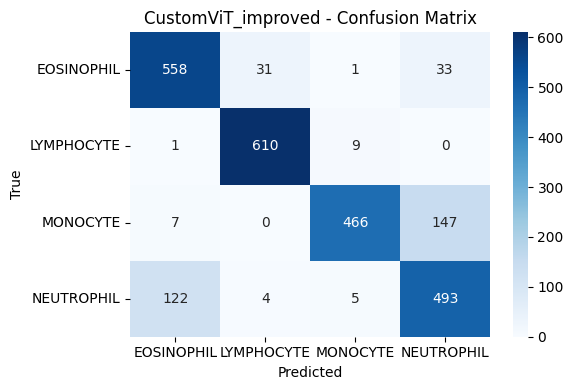

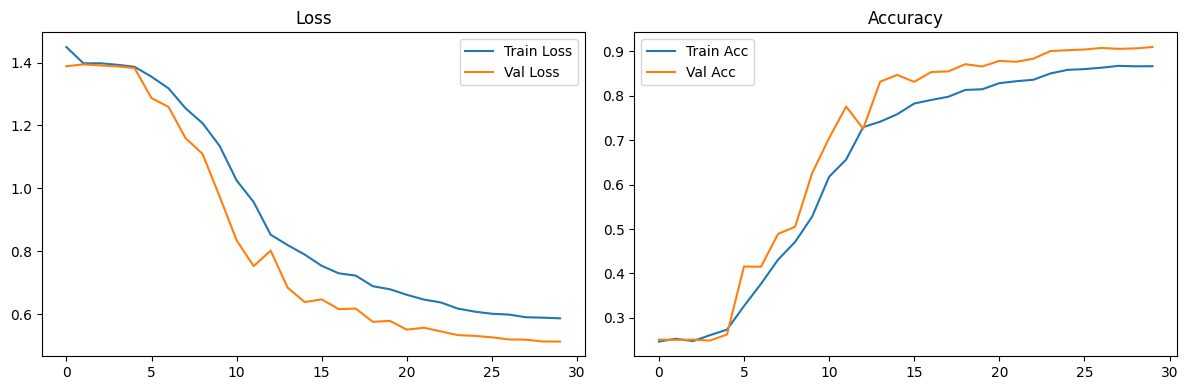


CustomViT_improved - Classification report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.81      0.90      0.85       623
  LYMPHOCYTE       0.95      0.98      0.96       620
    MONOCYTE       0.97      0.75      0.85       620
  NEUTROPHIL       0.73      0.79      0.76       624

    accuracy                           0.86      2487
   macro avg       0.86      0.86      0.86      2487
weighted avg       0.86      0.86      0.86      2487

Веса: outputs/custom_vit_improved.pth


In [ ]:
set_seed(SEED)
model = CustomViT(img_size=IMG_SIZE, num_classes=len(CLASS_NAMES)) # создание модели
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2) # создание оптимизатора
EPOCHS = 30 # количество эпох
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS) # создание scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # создание критерия

model, result = train_custom(
    model, "CustomViT_improved",
    train_loader, val_loader, test_loader,
    epochs=EPOCHS, optimizer=optimizer, scheduler=scheduler, criterion=criterion, device=DEVICE,
) # обучение модели

os.makedirs("outputs", exist_ok=True)
torch.save(model.state_dict(), "outputs/custom_vit_improved.pth") # сохранение весов модели
print("Веса: outputs/custom_vit_improved.pth")

Расширенный протокол обучения поднял результат до Accuracy 0.8552, Balanced Accuracy 0.8553, Macro-F1 0.8556 — прирост +2.6% относительно custom ViT baseline. 

Тем не менее отставание от кастомной CNN (0.8822) и тем более от Swin-T (0.8938) остаётся существенным (~3% и ~4% соответственно). Характерная особенность кривой обучения: эпохи 1–4 находились практически на уровне случайного угадания (~25% accuracy), лишь с эпохи 5 началось уверенное обучение — типичный «холодный старт» ViT без предобучения. Дополнительные 20 эпох, аугментация и weight_decay помогли, но фундаментальное ограничение — нехватка данных для трансформера — преодолеть не удалось.

In [ ]:
all_results = load_results()
all_results["CustomVIT_improved"] = result # добавление результатов модели в словарь всех результатов

df_cosine = pd.DataFrame([result]) # создание датафрейма с результатами модели
baseline_models = pd.DataFrame([
    all_results["baseline_resnet18"], # добавление результатов baseline модели ResNet18 в датафрейм
    all_results["baseline_swin"], # добавление результатов baseline модели Swin-T в датафрейм
    all_results["Swin_T_adamW_warmup"] # добавление результатов модели Swin-T с AdamW и warmup в датафрейм
])

df_compare = pd.concat([baseline_models, df_cosine], ignore_index=True) # объединение датафреймов

print("Baseline vs Swin_T_without_weights:")
display(df_compare[["model", "test_acc", "test_bal_acc", "test_f1_macro"]]) # отображение результатов
save_results(all_results)

Baseline vs Swin_T_without_weights:


,model,test_acc,test_bal_acc,test_f1_macro
0,ResNet18,0.854443,0.854462,0.858832
1,Swin-T,0.880177,0.880147,0.883016
2,Swin_T_adamW_warmup,0.893848,0.893787,0.895749
3,CustomViT_improved,0.855247,0.855304,0.855601


Результаты сохранены в outputs/experiment_results.pkl


Имплементация подтвердила общую закономерность: трансформеры, обученные с нуля, требуют значительно больших объёмов данных для достижения качества, сопоставимого с CNN. Прирост от улучшений есть, но архитектурное ограничение доминирует над выбором гиперпараметров.